Full name: Elsa Ingrid Daniela Erkfeldt
Civil nummer: 200309021228
LLM used: ChatGPT was used to get a deeper explanation for some slides in the PPT

In [ ]:
!pip install tensorflow
!pip install scikit-learn scikit-image

In [1]:
import tensorflow as tf
tf.random.set_seed(42)
from tensorflow.keras.datasets import mnist, cifar10
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras import callbacks
#Distance computation
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

from collections import Counter

2026-03-11 18:20:04.507690: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773253204.675849      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773253204.723170      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773253205.097106      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773253205.097156      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773253205.097159      55 computation_placer.cc:177] computation placer alr

Download the data sets and normalise the data
For MNIST:
    - Use min-max scaling, so that the values are in range[0,1]
For CIFAR-10:
    -Use Z score normalisation (mean=0, stdev=1)

In [2]:

(x_raw, y_raw), (x_test_raw, y_test)= mnist.load_data()

val_size = int(x_raw.shape[0] * 0.3)
rng = np.random.default_rng(42)  # seed for reproducibility
idx = np.arange(x_raw.shape[0])
rng.shuffle(idx)

val_idx = idx[:val_size]
train_idx = idx[val_size:]

(x_train_raw, y_train), (x_val_raw, y_val) = (x_raw[train_idx], y_raw[train_idx]), (x_raw[val_idx], y_raw[val_idx])


(x_raw_cif, y_cif), (x_test_cif_raw, y_test_cif) = cifar10.load_data()

val_size_cif = int(x_raw_cif.shape[0]*0.3)
idx_cif = np.arange(x_raw_cif.shape[0])
rng.shuffle(idx_cif)

val_idx_cif = idx_cif[:val_size_cif]
train_idx_cif = idx_cif[val_size_cif:]

(x_train_cif_raw, y_train_cif), (x_val_cif_raw, y_val_cif) = (x_raw_cif[train_idx_cif], y_cif[train_idx_cif]), (x_raw_cif[val_idx_cif], y_cif[val_idx_cif])

x_train_cif_type = x_train_cif_raw.astype("float32")
x_test_cif_type = x_test_cif_raw.astype("float32")
x_validation_cif_type = x_val_cif_raw.astype("float32")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
x_train, x_test, x_val= x_train_raw/255.0, x_test_raw/255.0, x_val_raw/255.0

def z_score_normalisation(train, test, validation):
    mean = np.mean(train, axis= (0,1,2), keepdims=True)
    std = np.std(train, axis= (0,1,2), keepdims=True)

    return (train - mean) / std, (test - mean) / std, (validation -mean) /std


x_train_cif, x_test_cif, x_val_cif = z_score_normalisation(x_train_cif_type, x_test_cif_type, x_validation_cif_type)



MNIST.
Train (with Adam optimizer) a CNN with:
    -First layer: Convolution layer wtih 16-64 filters (3x3), ReLu activation and batch normalisation
    -Second layer: Max pooling (2x2)
    -Third layer: Convolution layer with 32-128 filters (3x3), ReLu activation and batch normalisation
    -Fourth layer: max pooling (2x2)
    -Fifth layer: (after flattening the output from fourth later): A fully connected ("dense") layer with 128 neurons, ReLu activation (and dropout during training with suitable dropout range (somewhere in [0.2, 0.5]))
    -Sixth layer: a layer with 10 neurons (the number of classes) and a softmax activation function

In [4]:

model = models.Sequential([
    layers.Input(shape = (28,28,1)),
    #1
    layers.Conv2D(filters=16, kernel_size = (3,3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    #2
    layers.MaxPooling2D((2,2)),

    #3
    layers.Conv2D(filters=32, kernel_size=(3,3)),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    #4
    layers.MaxPooling2D((2,2)),

    #5
    layers.Flatten(),
    layers.Dense(128, activation = "relu"),
    layers.Dropout(0.4),

    #6
    layers.Dense(10, activation = "softmax")
])

model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"]) 
fitted = model.fit(x_train, y_train, epochs = 10, batch_size = 64, validation_data = (x_val, y_val))

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy: ", test_acc)


I0000 00:00:1773253343.364281      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773253343.370268      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/10


I0000 00:00:1773253346.856916     131 service.cc:152] XLA service 0x7ab2e4004590 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773253346.856953     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773253346.856957     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773253347.266268     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


 55/657 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4844 - loss: 1.6388

I0000 00:00:1773253350.559753     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


657/657 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8352 - loss: 0.5304 - val_accuracy: 0.9685 - val_loss: 0.1037
Epoch 2/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9682 - loss: 0.1046 - val_accuracy: 0.9829 - val_loss: 0.0590
Epoch 3/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9778 - loss: 0.0751 - val_accuracy: 0.9838 - val_loss: 0.0574
Epoch 4/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9804 - loss: 0.0615 - val_accuracy: 0.9866 - val_loss: 0.0466
Epoch 5/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9833 - loss: 0.0529 - val_accuracy: 0.9868 - val_loss: 0.0480
Epoch 6/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9851 - loss: 0.0467 - val_accuracy: 0.9877 - val_loss: 0.0411
Epoch 7/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9852 - loss: 0.0440 - val_accuracy: 0.9880 - val_loss: 0.0411
Epoch 8/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9884 - loss: 0.0345 - val_accuracy: 0.9876 - va

In [5]:

model_cif = models.Sequential([
    layers.Input(shape = (32,32,3)),
    #1
    layers.Conv2D(filters=16, kernel_size = (3,3), padding = "same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    #2
    layers.MaxPooling2D((2,2)),

    #3
    layers.Conv2D(filters=32, kernel_size=(3,3), padding = "same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    #4
    layers.MaxPooling2D((2,2)),

    #5
    layers.Conv2D(filters=32, kernel_size=(3,3), padding = "same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    #6
    layers.MaxPooling2D((2,2)),

    #5
    layers.Flatten(),
    layers.Dense(128, activation = "relu"),
    layers.Dropout(0.4),

    #6
    layers.Dense(10, activation = "softmax")
])

model_cif.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"]) 
fitted_cif = model_cif.fit(x_train_cif, y_train_cif, epochs = 10, batch_size = 64, validation_data = (x_val_cif, y_val_cif))

test_loss_cif, test_acc_cif = model_cif.evaluate(x_test_cif, y_test_cif)
print("Test accuracy: ", test_acc_cif)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.3264 - loss: 1.8905 - val_accuracy: 0.5167 - val_loss: 1.3288
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5101 - loss: 1.3543 - val_accuracy: 0.5938 - val_loss: 1.1378
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5666 - loss: 1.2019 - val_accuracy: 0.6169 - val_loss: 1.0670
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6153 - loss: 1.0899 - val_accuracy: 0.6587 - val_loss: 0.9733
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6416 - loss: 1.0140 - val_accuracy: 0.6489 - val_loss: 1.0042
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6649 - loss: 0.9526 - val_accuracy: 0.6786 - val_loss: 0.9158
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6775 - loss: 0.9150 - val_accuracy: 0.6797 - val_loss: 0.9162
Epoch 8/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6965 - loss: 0.8690 - val_accuracy: 

This one had a test Accuracy of 70%. To make it even better the following changes were made:


*   The number of filters for the Conv2D was adjusted so itstarted at 32, but increased for every layer
*   More convolution layers were added before each pooling too get a better representation of all the features before compressing it
* Pooling was used instead of flattten, to avoid it being too sensitive to the exact location of a pixel
* Dropout was added in more locations to avoid overfitting by forcing it to not rely on any specific feature too much.



In [6]:

model_cif2 = models.Sequential([

    layers.Input(shape = (32,32,3)),

    #1
    layers.Conv2D(filters=32, kernel_size = (3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    #2
    layers.Conv2D(filters=32, kernel_size = (3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    #3
    layers.MaxPooling2D((2,2)),

    #4
    layers.Conv2D(filters=64, kernel_size=(3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    #5
    layers.Conv2D(filters=64, kernel_size=(3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    #6
    layers.MaxPooling2D((2,2)),

    #7
    layers.Conv2D(filters=128, kernel_size=(3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    #8
    layers.Conv2D(filters=128, kernel_size=(3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    #9
    layers.MaxPooling2D((2,2)),

    #10
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation = "relu"),
    layers.Dropout(0.4),

    #11
    layers.Dense(10, activation = "softmax")
])

model_cif2.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"]) 
fitted_cif2 = model_cif2.fit(x_train_cif, y_train_cif, epochs = 10, batch_size = 64, validation_data = (x_val_cif, y_val_cif))

test_loss_cif2, test_acc_cif2 = model_cif2.evaluate(x_test_cif, y_test_cif)
print("Test accuracy: ", test_acc_cif2)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.3058 - loss: 1.9136 - val_accuracy: 0.4183 - val_loss: 1.6172
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5206 - loss: 1.3332 - val_accuracy: 0.5057 - val_loss: 1.3812
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5932 - loss: 1.1447 - val_accuracy: 0.4785 - val_loss: 1.4598
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6295 - loss: 1.0373 - val_accuracy: 0.5350 - val_loss: 1.3250
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6649 - loss: 0.9624 - val_accuracy: 0.6267 - val_loss: 1.0923
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6838 - loss: 0.9067 - val_accuracy: 0.6545 - val_loss: 1.0250
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7038 - loss: 0.8511 - val_accuracy: 0.6742 - val_loss: 0.9533
Epoch 8/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7216 - loss: 0.8071 - val_acc

Now the test accuracy has increased slightly to 73%, but we will try to improve it again. This time we added:


*   Early stopping to avoid overfitting and to save time (so it doesnt have to continue if it does not improve)
* Learning rate scheduler: Learning rate is decreased if the model stops improving


In [11]:

model_cif = models.Sequential([

    layers.Input(shape = (32,32,3)),

    #1
    layers.Conv2D(filters=32, kernel_size = (3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.1),

    #2
    layers.Conv2D(filters=32, kernel_size = (3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.1),

    #3
    layers.MaxPooling2D((2,2)),

    #4
    layers.Conv2D(filters=64, kernel_size=(3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.2),

    #5
    layers.Conv2D(filters=64, kernel_size=(3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.2),

    #6
    layers.MaxPooling2D((2,2)),

    #7
    layers.Conv2D(filters=128, kernel_size=(3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    #8
    layers.Conv2D(filters=128, kernel_size=(3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    #9
    layers.MaxPooling2D((2,2)),

    #10
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation = "relu"),
    layers.Dropout(0.4),

    #11
    layers.Dense(10, activation = "softmax")
])

model_cif.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"]) 
early_stopping = callbacks.EarlyStopping(monitor = "val_loss", patience = 4, restore_best_weights = True)
learning_rate = callbacks.ReduceLROnPlateau(monitor = "val_loss", factor = 0.5, patience = 3, min_lr = 1e-5)
fitted_cif = model_cif.fit(x_train_cif, y_train_cif, epochs = 30, batch_size = 64, validation_data = (x_val_cif, y_val_cif), callbacks = [early_stopping, learning_rate])

test_loss_cif, test_acc_cif = model_cif.evaluate(x_test_cif, y_test_cif)
print("Test accuracy: ", test_acc_cif)

Epoch 1/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.3441 - loss: 1.8006 - val_accuracy: 0.4478 - val_loss: 1.5755 - learning_rate: 0.0010
Epoch 2/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5651 - loss: 1.2180 - val_accuracy: 0.5757 - val_loss: 1.2210 - learning_rate: 0.0010
Epoch 3/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6307 - loss: 1.0425 - val_accuracy: 0.6362 - val_loss: 1.0334 - learning_rate: 0.0010
Epoch 4/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6732 - loss: 0.9296 - val_accuracy: 0.6409 - val_loss: 0.9871 - learning_rate: 0.0010
Epoch 5/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7052 - loss: 0.8458 - val_accuracy: 0.6920 - val_loss: 0.8961 - learning_rate: 0.0010
Epoch 6/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7303 - loss: 0.7875 - val_accuracy: 0.6621 - val_loss: 0.9782 - learning_rate: 0.0010
Epoch 7/30
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7446 - loss: 0

This change lead to a huge improvement in the test accuracy, at 83.7%. This model was therefore picked

Implement kNN models for both MNISTA and CIFAR.
Use the standard euclidean distance measure (applied pixel-by picel)
Run each model with different values of k (from 1-25 eg.). Pick the k with the highers validation accuracy.
Use that to obtain testing accuracy

Flatten each image
Scale data (min-max scaling to put all values in [0, 1])
Distance computation: sum distances (squared, if euclidean norm) over all elements, computed pixel by pixel (compare test image pixels with those of image Ii in data set)
sort (together with label) the distances in increasing order
voting: take the majority label among the k-nearest neighbours

In [12]:

def flatten(x):
    return x.reshape(x.shape[0], -1)

flattened_x_train, flattened_x_test, flattened_x_val = flatten(x_train), flatten(x_test), flatten(x_val)

flattened_x_train_CIFAR, flattened_x_test_CIFAR, flattened_x_val_CIFAR = flatten(x_train_cif), flatten(x_test_cif), flatten(x_val_cif)


Functions for KNN. They are however not used in the rest of the code as each time I tried to use it Colab told me that I was out of alla vailable RAM and that my session had crashed

In [13]:
class KNN():
  def __init__(self, k):
    self.k = k
    self.x_train = None
    self.y_train = None

  def fit(self, x_train, y_train):
    self.x_train = x_train
    self.y_train = y_train

  def predict(self, x_test):

    dists = np.sqrt(np.sum(x_test**2, axis = 1)[:, None] +
                    np.sum(self.x_train**2, axis=1)[None, :] -
                    2* x_test @ self.x_train.T)
    knn_index = np.argpartitions(dists, self.k, axis =1)[:, :self.k]

    knn_labels = self.y_train[knn_index]
    predictions = np.array([Counter(row).most_common(1)[0][0] for row in knn_labels])

    return predictions

  def kneighbours(self, x_test_line, n_neighbours):
    dist = np.sqrt(np.sum(x_test_line**2) + np.sum(self.x_train**2, aaxis=1)- 2*(self.x_train@x_test_line))

    index = np.argpartition(dist, n_neighbours)[:n_neighbours]
    return dist[idx], idx


MNIST finding best n_neighbours
And test accuracy for the best one

In [14]:
best_k, best_acc = None, -1.0
for k in range(1,26):
    knn = KNeighborsClassifier(n_neighbors=k, metric = "euclidean", weights="uniform")

    knn.fit(flattened_x_train, y_train)
    prediction = knn.predict(flattened_x_val)

    acc = accuracy_score(y_val, prediction)
    print("Accuracy: ", acc, " for k = ", k)
    if acc > best_acc:
        best_acc = acc
        best_k = k

#Test with best k
knn = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean", weights="uniform")
knn.fit(flattened_x_train, y_train)
test_acc = accuracy_score(y_test, knn.predict(flattened_x_test))
print("Test accuracy: ", test_acc)

Accuracy:  0.9712777777777778  for k =  1
Accuracy:  0.9645  for k =  2
Accuracy:  0.9701111111111111  for k =  3
Accuracy:  0.9696111111111111  for k =  4
Accuracy:  0.9701666666666666  for k =  5
Accuracy:  0.969  for k =  6
Accuracy:  0.9688888888888889  for k =  7
Accuracy:  0.9683888888888889  for k =  8
Accuracy:  0.9668888888888889  for k =  9
Accuracy:  0.9652222222222222  for k =  10
Accuracy:  0.9655  for k =  11
Accuracy:  0.9645555555555556  for k =  12
Accuracy:  0.9642222222222222  for k =  13
Accuracy:  0.9635555555555556  for k =  14
Accuracy:  0.9629444444444445  for k =  15
Accuracy:  0.9629444444444445  for k =  16
Accuracy:  0.9621111111111111  for k =  17
Accuracy:  0.9612777777777778  for k =  18
Accuracy:  0.9608888888888889  for k =  19
Accuracy:  0.9602222222222222  for k =  20
Accuracy:  0.9596111111111111  for k =  21
Accuracy:  0.9596111111111111  for k =  22
Accuracy:  0.9583333333333334  for k =  23
Accuracy:  0.9578333333333333  for k =  24
Accuracy:  0.9

The best one was k=1 with a validation accuracy of 97% and a test accuracy of 96.6 %

Doing the same for CIFAR

In [16]:
best_acc_CIF = 0
best_k_CIF = None
for k in range(1,26):
    knn = KNeighborsClassifier(n_neighbors = k, metric="euclidean", weights = "uniform")

    knn.fit(flattened_x_train_CIFAR, y_train_cif)
    prediction = knn.predict(flattened_x_val_CIFAR)

    acc = accuracy_score(y_val_cif, prediction)
    print("Accuracy: ", acc, " for k = ", k)
    if acc > best_acc_CIF:
        best_acc_CIF = acc
        best_k_CIF = k

#Test with best k
knn_cif = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean", weights="uniform")
knn_cif.fit(flattened_x_train_CIFAR, y_train_cif)
test_acc_cif = accuracy_score(y_test_cif, knn_cif.predict(flattened_x_test_CIFAR))
print("Test accuracy: ", test_acc_cif)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.3369333333333333  for k =  1


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.3048666666666667  for k =  2


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


...

Accuracy:  0.3168666666666667  for k =  24


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.3164666666666667  for k =  25


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Test accuracy:  0.3363


In [21]:
test_examples = [0, 5, 50, 500, 5000]

k = 4


Here it shows the image and the nearest neighbour for each of a few classified test images

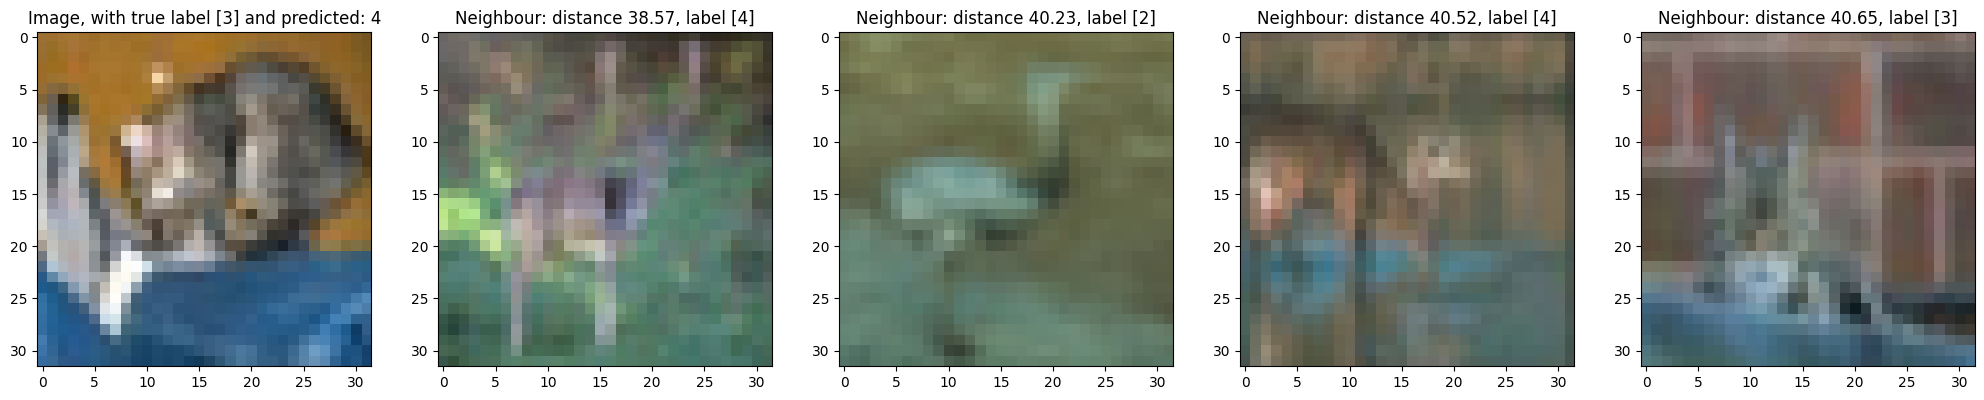

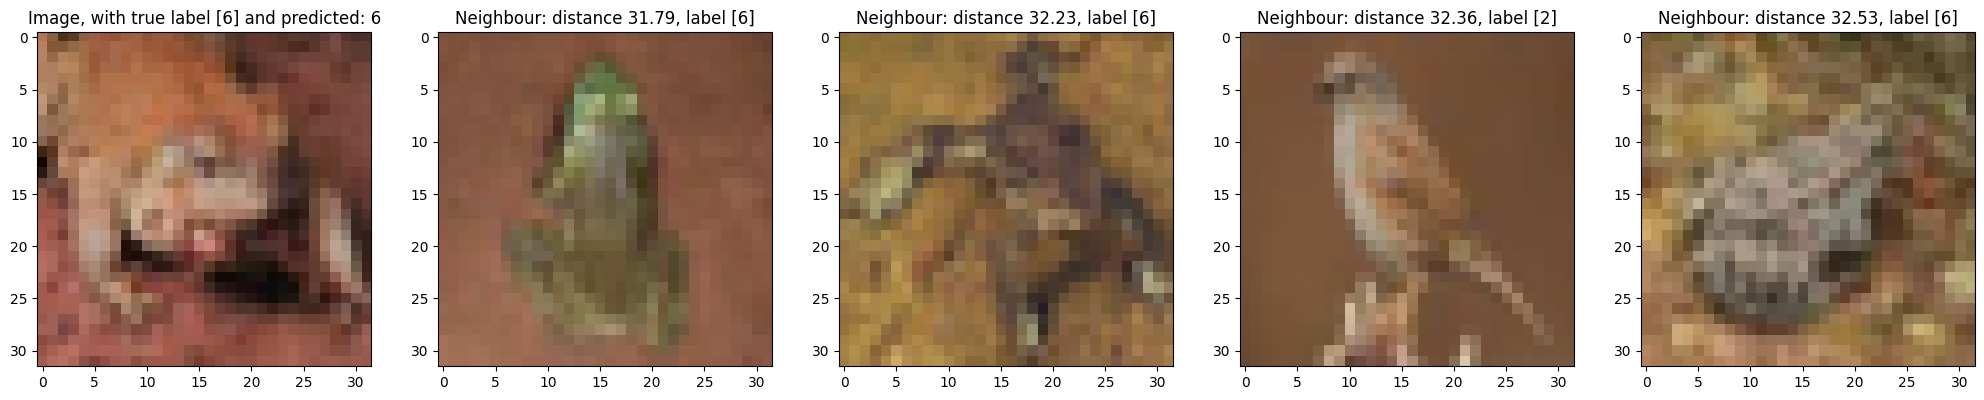

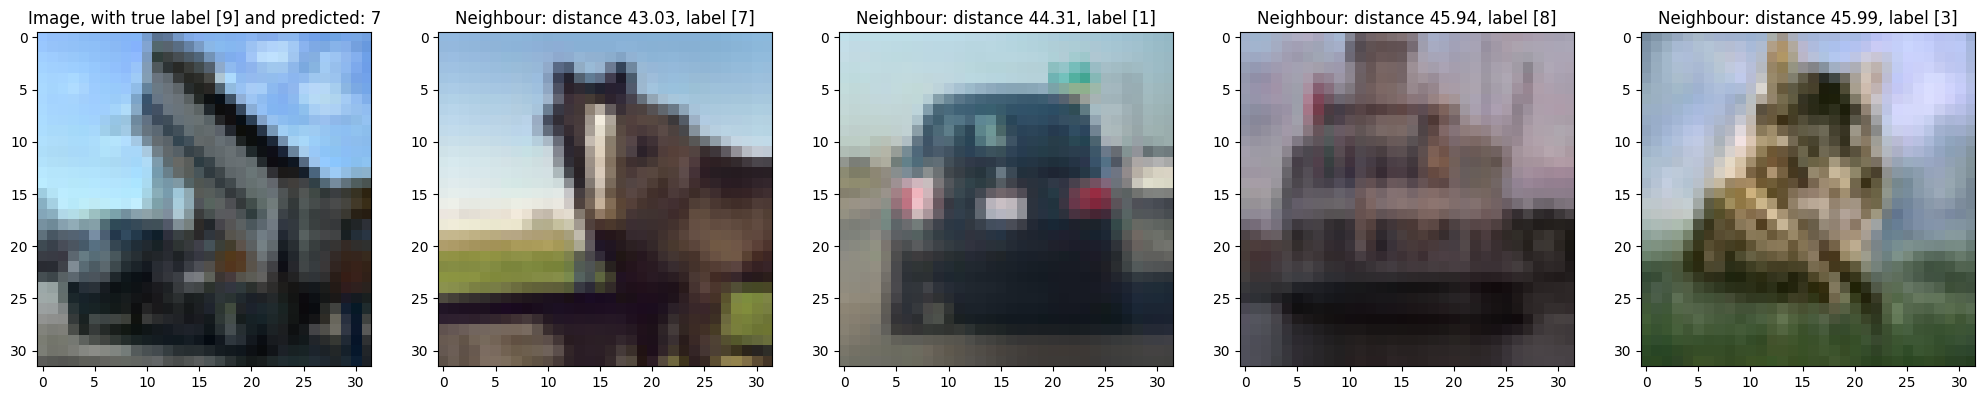

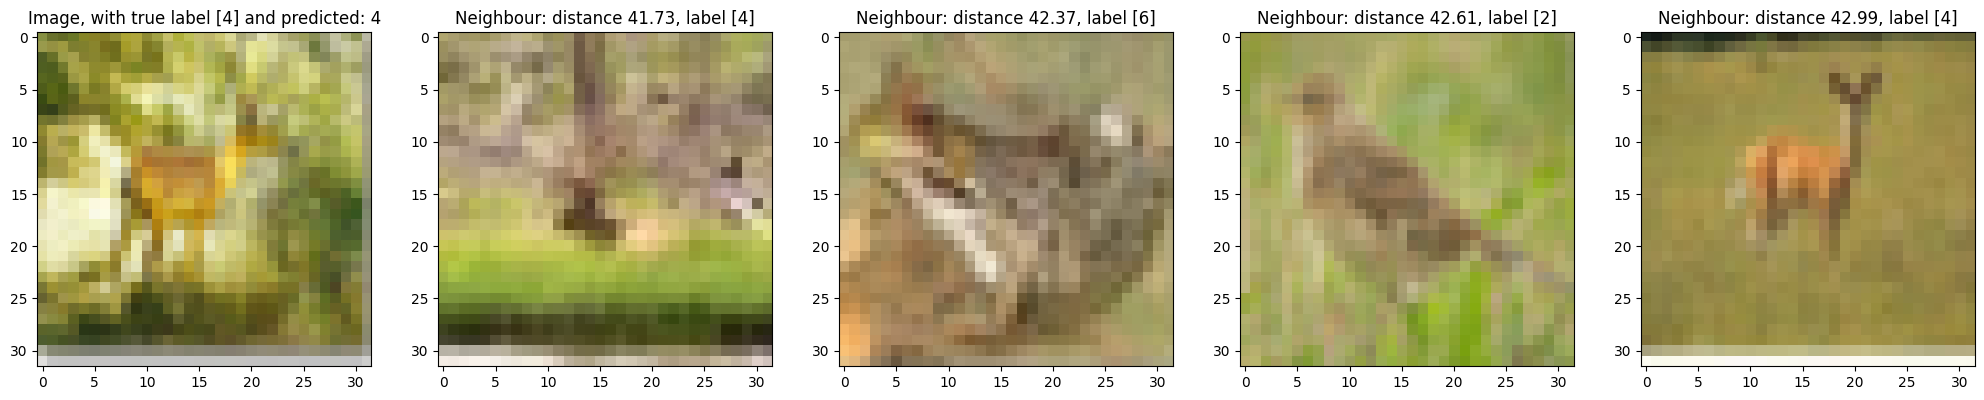

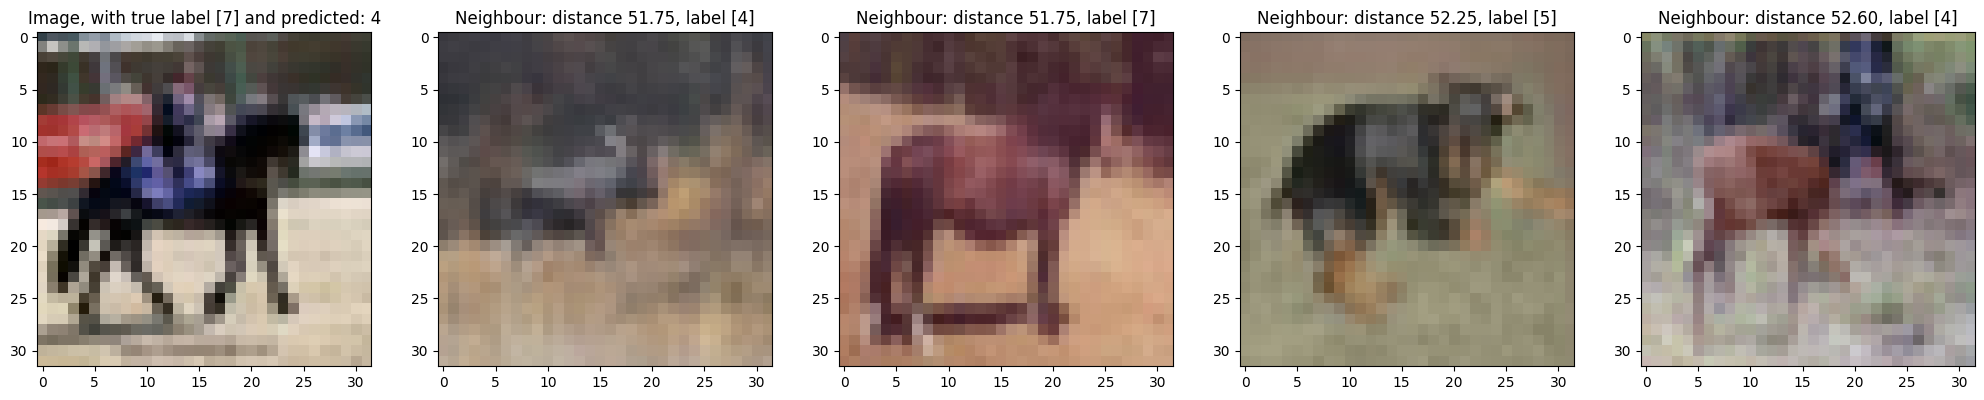

In [41]:
for idx in test_examples:
    image_used = flattened_x_test_CIFAR[idx].reshape(1, -1)
    distance, indices = knn_cif.kneighbors(image_used, n_neighbors = k, return_distance= True)
    indices = indices[0]
    distance = distance [0]
    predicted = knn_cif.predict(image_used)[0]

    plt.figure(figsize=(25,25))
    plt.subplot(1, 5, 1)
    plt.imshow(x_test_cif_raw[idx])
    plt.title(f"Image, with true label {y_test_cif[idx]} and predicted: {predicted}")

    for i in range(len(indices)):
        plt.subplot(1, 5, i+2)
        plt.imshow(x_train_cif_raw[indices[i]])
        plt.title(f"Neighbour: distance {distance[i]:.2f}, label {y_train_cif[indices[i]]}")

    plt.show()

Comparing the images with their knearestneighbours, especially those that were predicted to be something other than what they are, one can get an idea of what the model bases its classifications on.
It seems like a lot is based on the background, as most of the iamges have a similar background to their knearestneighbours, even when they have different true classes. 
It makes sense that the model based a lot of its assumption on this for several reasons. First of all the images are low in resolution, making it hard to see the smaller and specific features that make it possible to differentiate differnet types. Secondly, the same thing is often found in the same context (ie with the same background) and the background usually take up most of the image, so it makes sense that the model bases a lot of its predictions on that.